In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

In [2]:
# Load the cleaned CSV file
df = pd.read_csv(
    "termstructure.csv",
    sep=',',
    decimal='.',
#    encoding="utf-8-sig",
    parse_dates=['Datum'],   # or use actual column name
)


In [3]:
# Time Span of the Dataset
start_date = df['Datum'].min()
end_date = df['Datum'].max()
print(f"Data set spans from {start_date.date()} until {end_date.date()}")

Data set spans from 2019-02-01 until 2026-04-29


Measures for the level, slope and curvature of the term structure may be obtained from rates with maturities of 2, 5, and 10 years. The market characteristics are determined as in Blaskowitz & Herwartz (2011)

- lev = (2yrs+5yrs+10yrs)/3 (level)
- slo = (10yrs − 2yrs)/2 (slope) 
- cur = 2yrs/4 − 5yrs/2 + 10yrs/4 (curvature)

In [4]:
# Calculate Level,Slope, and Curvature of the yield curve

# level
df['level'] = (df['2 Jahre'] + df['5 Jahre'] + df['10 Jahre']) / 3
# slope
df['slope'] = (df['10 Jahre'] - df['2 Jahre']) / 2
# curvature
df['curvature'] = (df['2 Jahre']/4 - df['5 Jahre'] /2 + df['10 Jahre'] /4 ) 

In [5]:
df.dtypes

Datum        datetime64[ns]
1 Monat             float64
2 Monate            float64
3 Monate            float64
6 Monate            float64
9 Monate            float64
1 Jahr              float64
1.5 Jahre           float64
2 Jahre             float64
3 Jahre             float64
4 Jahre             float64
5 Jahre             float64
6 Jahre             float64
7 Jahre             float64
8 Jahre             float64
9 Jahre             float64
10 Jahre            float64
level               float64
slope               float64
curvature           float64
dtype: object

In [6]:
df.head(5)

,Datum,1 Monat,2 Monate,3 Monate,6 Monate,9 Monate,1 Jahr,1.5 Jahre,2 Jahre,3 Jahre,4 Jahre,5 Jahre,6 Jahre,7 Jahre,8 Jahre,9 Jahre,10 Jahre,level,slope,curvature
0,2019-02-01,0.13,0.13,0.7,0.81,0.58,1.18,0.90,1.3,1.41,1.49,1.71,1.34,1.43,1.43,1.34,1.8,1.603333,0.25,-0.08
1,2019-02-02,0.13,0.13,0.7,0.82,0.58,1.18,0.90,1.3,1.42,1.49,1.71,1.34,1.43,1.43,1.34,1.8,1.603333,0.25,-0.08
2,2019-02-03,0.13,0.13,0.7,0.82,0.58,1.18,0.88,1.3,1.42,1.49,1.71,1.34,1.43,1.43,1.34,1.8,1.603333,0.25,-0.08
3,2019-02-04,0.13,0.13,0.7,0.82,0.58,1.18,0.88,1.3,1.42,1.49,1.71,1.34,1.43,1.43,1.34,1.8,1.603333,0.25,-0.08
4,2019-02-05,0.13,0.13,0.7,0.82,0.58,1.18,0.88,1.3,1.42,1.49,1.71,1.34,1.43,1.43,1.34,1.8,1.603333,0.25,-0.08


In [7]:
df.describe()

,1 Monat,2 Monate,3 Monate,6 Monate,9 Monate,1 Jahr,1.5 Jahre,2 Jahre,3 Jahre,4 Jahre,5 Jahre,6 Jahre,7 Jahre,8 Jahre,9 Jahre,10 Jahre,level,slope,curvature
count,2645.000000,2638.000000,2645.000000,2645.000000,2645.000000,2645.000000,2645.000000,2645.000000,2645.000000,2645.000000,2645.000000,2645.000000,2645.000000,2645.000000,2645.000000,2645.000000,2645.000000,2645.000000,2645.000000
mean,1.023629,0.936425,1.649856,1.870544,1.791380,2.141036,1.907992,2.278749,2.355055,2.324544,2.429762,2.046227,2.096389,1.979754,1.870522,2.314541,2.341017,0.017896,-0.066559
std,1.067351,0.917676,1.304918,1.312891,1.328865,1.261995,1.227340,1.181501,1.146373,1.117905,1.074898,1.089011,1.059306,0.985607,0.981311,0.942018,1.062366,0.155496,0.041209
min,0.040000,0.010000,0.260000,0.390000,0.340000,0.620000,0.360000,0.880000,0.950000,0.900000,1.040000,0.610000,0.720000,0.670000,0.520000,1.110000,1.023333,-0.395000,-0.182500
25%,0.100000,0.130000,0.440000,0.640000,0.550000,0.980000,0.850000,1.170000,1.270000,1.260000,1.400000,1.020000,1.020000,1.010000,0.900000,1.340000,1.293333,-0.080000,-0.095000
50%,0.200000,0.330000,0.700000,1.140000,1.170000,2.000000,1.410000,2.200000,2.370000,2.250000,2.350000,1.850000,2.010000,1.760000,1.740000,2.140000,2.230000,0.075000,-0.062500
75%,2.070000,1.790000,2.750000,2.880000,2.880000,3.130000,2.850000,3.280000,3.320000,3.310000,3.430000,3.000000,3.050000,2.900000,2.790000,3.150000,3.270000,0.125000,-0.040000
max,2.830000,2.590000,3.920000,4.240000,4.190000,4.520000,4.190000,4.530000,4.570000,4.460000,4.510000,4.000000,3.920000,3.650000,3.530000,4.030000,4.346667,0.255000,0.037500


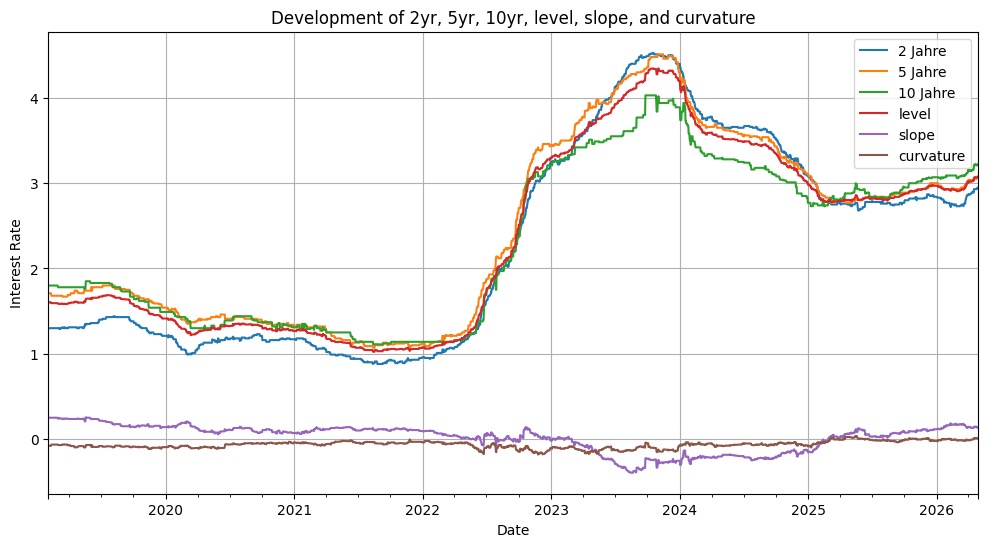

In [8]:
# Graph for 2yr, 5yr, 10yr, level, slope, and curvature
cols = ["2 Jahre", "5 Jahre", "10 Jahre", "level", "slope", "curvature"]

# use date column as x-axis
df.plot(x="Datum", y=cols, figsize=(12,6))

plt.title("Development of 2yr, 5yr, 10yr, level, slope, and curvature")
plt.xlabel("Date")
plt.ylabel("Interest Rate")
plt.grid(True)
plt.legend()
plt.show()

The slope of the yield curve is one of the most closely watched signals in macroeconomics because it reflects expectations about growth, 
inflation, and monetary policy.

Why the slope matters:
1. Economic growth expectations
	- Upward-sloping (normal curve): Long-term rates are higher than short-term rates
		→ Investors expect stronger growth and possibly higher inflation.
	- Flat curve: Little difference between short and long rates
		→ Signals uncertainty or a transition phase in the economy.
	- Inverted curve (downward slope): Short-term rates exceed long-term rates
		→ Often interpreted as a warning of an upcoming recession.
		
2. Recession indicator
	An inverted yield curve has historically been one of the most reliable predictors of recessions.
	For example:
		Before the 2008 financial crisis, the yield curve inverted in 2006–2007.
		Similar patterns appeared before earlier downturns in the U.S. and other economies.
	The logic:
		Investors expect central banks to cut rates in the future due to slowing growth.
		So they accept lower yields on long-term bonds.

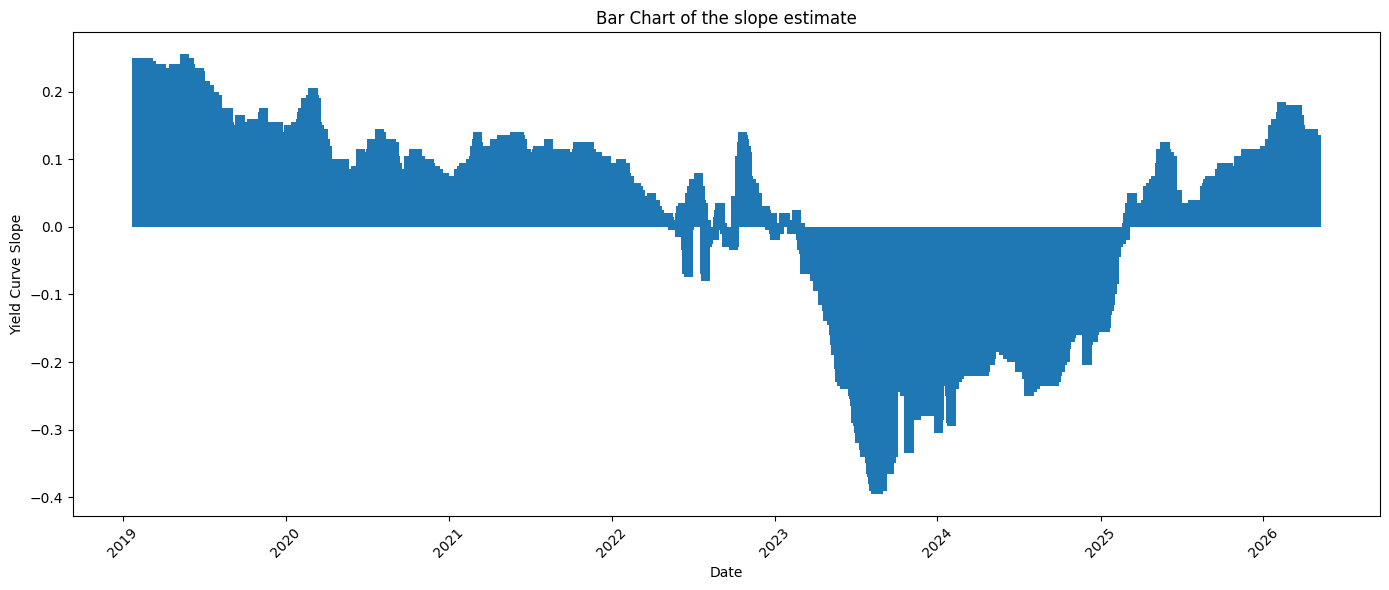

In [9]:
# bar chart for the slope estimation
fig, ax = plt.subplots(figsize=(14,6))

ax.bar(df["Datum"], df["slope"], width=20)   # width in days

# show fewer date labels
ax.xaxis.set_major_locator(mdates.YearLocator())         # one tick per year
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# optional: rotate labels
plt.xticks(rotation=45)

plt.title("Bar Chart of the slope estimate")
plt.xlabel("Date")
plt.ylabel("Yield Curve Slope")
plt.tight_layout()
plt.show()


Factor Model
The motivation for using factor analysis and PCA is the idea that a large set of N variables can be explained by a smaller set of R factors or principal components.

X =F A′ + E

X = (˜x′•,1,..., ˜x′•,τ)′ = (˜x1,•, . . . , ˜xN,•) is a τ × N matrix of N appropriately transformed variables. Xs is observed in a time window of length τ. 

F = (f′•,1,...,f′•,τ)′ = (f1,•,...,fR,•) are R unobservable factors in a τ × R matrix

A is a N × R matrix of loadings

E is a τ × N matrix of disturbances

A and F, are the eigenvectors ˆa•,r corresponding to the largest eigenvalues λr,r = 1,...,R, of the matrix (˜X′X) and F = XA

Ex-ante prediction is performed on the deviations from unconditional in-sample means, ˜ym,t = ym,t−¯ym,s, where ¯ym,s = 1τ Ps t=s−(τ−1) ym,t.
Forecasts of vectors ˜ys+h are throughout determined by means of sample information available at time s, Ξs,τ = {˜xt|t = s − (τ − 1),...,s}. Thus these are pseudo ex-ante forecasting exercises. These forecasts ys+h|s = E[˜ys+h|Ξs,τ] + ¯ys can then also be used to forecast level, slope and curvature of the term structure.


In [10]:
# Parameters for Factor estimation
# Used forecast horizons
HH=[1,5,10,15]		

# For PCA used time windows
TAU = [42,63,126,189,252]	# For PCA used time windows

# Possible Amount of Factors
RR = list(range(1,5))  		

# Possible Lags
PP = list(range(0,4))  		

In [34]:
# Maturities used for factor estimation
cols = [#'1 Monat', 
        #'2 Monate', 
        #'3 Monate', 
        #'6 Monate', 
        #'9 Monate',
        '1 Jahr', 
        '1.5 Jahre', 
        '2 Jahre', 
        '3 Jahre', 
        '4 Jahre', 
        '5 Jahre',
        '6 Jahre', 
        '7 Jahre', 
        '8 Jahre', 
        '9 Jahre', 
        '10 Jahre']

In [35]:
# Extraction for time window with size Tau 
# sub = df[cols].iloc[:42] - df[cols].iloc[:42].mean()
# X =  sub.to_numpy()
X_tilde = df[cols].iloc[:42].to_numpy()
X = X_tilde - X_tilde.mean(axis=0)

In [36]:
print(X.shape)

(42, 11)


In [37]:
# X'X Matrix
XX = X.T @ X

In [38]:
# 
XX.shape

(11, 11)

In [39]:
lambdas, A_tilde = np.linalg.eig(XX)

In [40]:
print(lambdas)

[ 2.91817421e-02  9.39295841e-03  1.26556437e-03  7.22290109e-04
  2.86345023e-04  1.87703740e-04  5.63574177e-05  5.26086410e-04
 -4.66563297e-19 -4.08905223e-18 -2.23183575e-20]


In [42]:
A_tilde[0,:]

array([ 5.66340219e-03, -1.10515321e-02,  6.15888850e-01,  4.97376154e-01,
        5.81544701e-01, -1.31641124e-01,  1.32736649e-01,  1.01671712e-03,
       -8.68209678e-16,  2.92736970e-15, -2.49100299e-17])

In [33]:
lambdas

array([ 4.62755373e-02,  1.34443288e-02,  6.75843765e-03,  2.31136308e-03,
        8.23333414e-04,  6.88397507e-04,  6.73636846e-04,  2.64067302e-04,
        1.90380340e-04,  1.51182161e-04,  3.36212585e-05, -4.27956308e-18,
       -1.07033424e-18, -4.27338973e-20,  0.00000000e+00,  0.00000000e+00])

In [32]:
lambdas/ lambdas.sum()

array([ 6.46177461e-01,  1.87732499e-01,  9.43727580e-02,  3.22751677e-02,
        1.14967762e-02,  9.61257241e-03,  9.40645906e-03,  3.68735510e-03,
        2.65841288e-03,  2.11106149e-03,  4.69476978e-04, -5.97585110e-17,
       -1.49458202e-17, -5.96723082e-19,  0.00000000e+00,  0.00000000e+00])

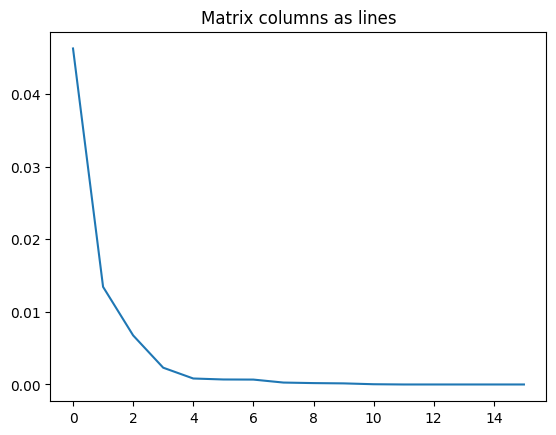

In [30]:
plt.plot(lambdas)   # plots each column as a separate line
plt.title("Matrix columns as lines")
plt.show()